In [1]:
import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt

matplotlib.style.use('ggplot')
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

import os

In [2]:
from src.config import FILE_BEVERAGE, ENCODINGS, FILE_ASSESS

In [3]:
os.chdir(r"C:\Users\print\OneDrive\Рабочий стол\Data_Analysis_in_Python\claster_analisis\data")

In [4]:
os.getcwd()

'C:\\Users\\print\\OneDrive\\Рабочий стол\\Data_Analysis_in_Python\\claster_analisis\\data'

In [5]:
df = pd.read_csv(FILE_BEVERAGE, encoding=ENCODINGS[0], sep=';', index_col='numb.obs')
df2 = pd.read_csv(FILE_BEVERAGE, encoding=ENCODINGS[0], sep=';', index_col='numb.obs')

In [6]:
df.head(5)

,COKE,D_COKE,D_PEPSI,D_7UP,PEPSI,SPRITE,TAB,SEVENUP
numb.obs,,,,,,,,
1,1,0,0,0,1,1,0,1
2,1,0,0,0,1,0,0,0
3,1,0,0,0,1,0,0,0
4,0,1,0,1,0,0,1,0
5,1,0,0,0,1,0,0,0


In [7]:
df.tail(5)

,COKE,D_COKE,D_PEPSI,D_7UP,PEPSI,SPRITE,TAB,SEVENUP
numb.obs,,,,,,,,
30,0,1,1,0,0,0,1,0
31,1,0,0,0,1,0,0,1
32,0,1,1,0,0,0,1,0
33,1,0,0,0,1,0,0,1
34,0,1,1,1,0,0,1,0


In [8]:
print(df)

          COKE  D_COKE  D_PEPSI  D_7UP  PEPSI  SPRITE  TAB  SEVENUP
numb.obs                                                           
1            1       0        0      0      1       1    0        1
2            1       0        0      0      1       0    0        0
3            1       0        0      0      1       0    0        0
4            0       1        0      1      0       0    1        0
5            1       0        0      0      1       0    0        0
6            1       0        0      0      1       1    0        0
7            0       1        1      1      0       0    1        0
8            1       1        0      0      1       1    0        1
9            1       1        0      0      0       1    1        1
10           1       0        0      0      1       0    0        1
11           1       0        0      0      1       1    0        0
12           0       1        0      0      0       0    1        0
13           0       0        1      1      0   

In [9]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [10]:
Z = linkage(df, method='ward', metric='euclidean')

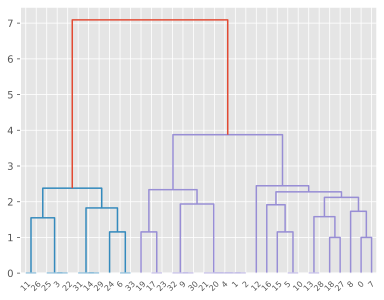

In [11]:
dendrogram(Z);

In [12]:
print(Z)

[[ 5.         10.          0.          2.        ]
 [ 1.          2.          0.          2.        ]
 [ 4.         35.          0.          3.        ]
 [ 3.         22.          0.          2.        ]
 [20.         36.          0.          4.        ]
 [ 6.         33.          0.          2.        ]
 [ 9.         30.          0.          2.        ]
 [13.         28.          0.          2.        ]
 [32.         40.          0.          3.        ]
 [17.         23.          0.          2.        ]
 [11.         26.          0.          2.        ]
 [14.         29.          0.          2.        ]
 [25.         37.          0.          3.        ]
 [31.         45.          0.          3.        ]
 [21.         38.          0.          5.        ]
 [ 0.          7.          1.          2.        ]
 [18.         27.          1.          2.        ]
 [15.         34.          1.15470054  3.        ]
 [24.         39.          1.15470054  3.        ]
 [19.         43.          1.15

In [13]:
print(type(Z))
print(Z.shape)

<class 'numpy.ndarray'>
(33, 4)


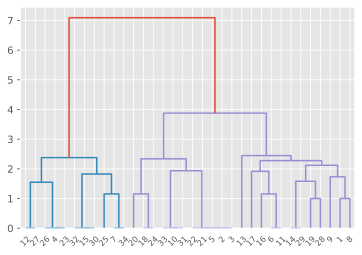

In [14]:
fig = plt.figure(figsize = (6,4))
dn = dendrogram(Z, labels=df.index.tolist())

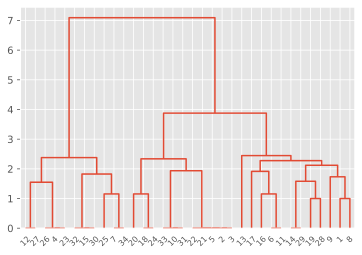

In [15]:
fig = plt.figure(figsize=(6,4))
dn = dendrogram(Z, color_threshold=-1, labels=df.index.tolist())

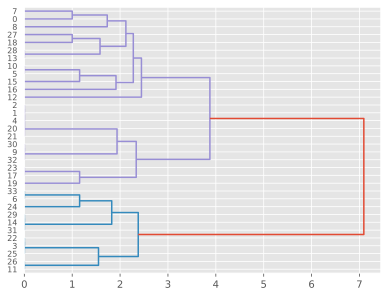

In [16]:
dn = dendrogram(Z, orientation = "right")

In [17]:
df['cluster'] = fcluster(Z, t=3.1, criterion='distance')
#df['cluster'] = fcluster(Z, 3, criterion='maxclust')

In [18]:
df

,COKE,D_COKE,D_PEPSI,D_7UP,PEPSI,SPRITE,TAB,SEVENUP,cluster
numb.obs,,,,,,,,,
1,1,0,0,0,1,1,0,1,3
2,1,0,0,0,1,0,0,0,2
3,1,0,0,0,1,0,0,0,2
4,0,1,0,1,0,0,1,0,1
5,1,0,0,0,1,0,0,0,2
6,1,0,0,0,1,1,0,0,3
7,0,1,1,1,0,0,1,0,1
8,1,1,0,0,1,1,0,1,3
9,1,1,0,0,0,1,1,1,3


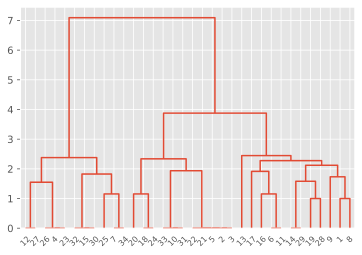

In [19]:
fig = plt.figure(figsize=(6,4))
dn = dendrogram(Z, color_threshold=-1, labels=df.index.tolist())

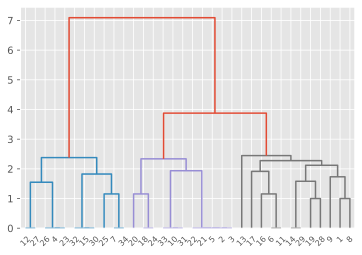

In [20]:
fig = plt.figure(figsize=(6,4))
dn = dendrogram(Z, color_threshold=3.2, labels=df.index.tolist())

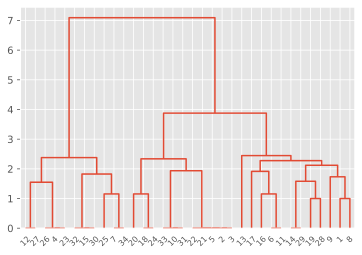

In [21]:
fig = plt.figure(figsize=(6,4))
dn = dendrogram(Z, color_threshold=-1, labels=df.index.tolist())

In [22]:
dfc = df.copy()
dfc['cluster'].value_counts().sort_index()

cluster
1    11
2    11
3    12
Name: count, dtype: int64

In [23]:
profile = dfc.groupby('cluster').mean().round(2)
profile

,COKE,D_COKE,D_PEPSI,D_7UP,PEPSI,SPRITE,TAB,SEVENUP
cluster,,,,,,,,
1,0.00,1.00,0.55,0.55,0.00,0.00,0.91,0.00
2,1.00,0.27,0.09,0.00,1.00,0.00,0.00,0.27
3,0.75,0.25,0.08,0.08,0.42,0.92,0.08,0.50


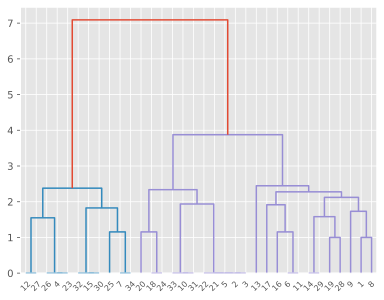

In [24]:
dn2 = dendrogram(Z, color_threshold=6, labels=df.index.tolist())

In [25]:
df2['cluster'] = fcluster(Z, t=6, criterion='distance')

In [26]:
df2

,COKE,D_COKE,D_PEPSI,D_7UP,PEPSI,SPRITE,TAB,SEVENUP,cluster
numb.obs,,,,,,,,,
1,1,0,0,0,1,1,0,1,2
2,1,0,0,0,1,0,0,0,2
3,1,0,0,0,1,0,0,0,2
4,0,1,0,1,0,0,1,0,1
5,1,0,0,0,1,0,0,0,2
6,1,0,0,0,1,1,0,0,2
7,0,1,1,1,0,0,1,0,1
8,1,1,0,0,1,1,0,1,2
9,1,1,0,0,0,1,1,1,2


In [27]:
profile2 = df2.groupby('cluster').mean().round(2)
profile2

,COKE,D_COKE,D_PEPSI,D_7UP,PEPSI,SPRITE,TAB,SEVENUP
cluster,,,,,,,,
1,0.00,1.00,0.55,0.55,0.0,0.00,0.91,0.00
2,0.87,0.26,0.09,0.04,0.7,0.48,0.04,0.39


In [28]:
df2['cluster'].value_counts().sort_index()

cluster
1    11
2    23
Name: count, dtype: int64

In [29]:
df2.groupby('cluster').size() # 2й вариант подсчета столбца(лучше использовать его)

cluster
1    11
2    23
dtype: int64

In [30]:
df['cluster'].value_counts().sort_index()

cluster
1    11
2    11
3    12
Name: count, dtype: int64

In [31]:
df.groupby('cluster').size() # 2й вариант подсчета столбца(лучше использовать его)

cluster
1    11
2    11
3    12
dtype: int64

In [32]:
df[df['cluster']==1].index.values

array([ 4,  7, 12, 15, 23, 25, 26, 27, 30, 32, 34], dtype=int64)

In [33]:
df.groupby(fcluster(Z, t=2, criterion='maxclust')).mean()

,COKE,D_COKE,D_PEPSI,D_7UP,PEPSI,SPRITE,TAB,SEVENUP,cluster
1,0.000000,1.00000,0.545455,0.545455,0.000000,0.000000,0.909091,0.000000,1.000000
2,0.869565,0.26087,0.086957,0.043478,0.695652,0.478261,0.043478,0.391304,2.521739


In [34]:
df.groupby(fcluster(Z, t=4, criterion='maxclust')).mean()

,COKE,D_COKE,D_PEPSI,D_7UP,PEPSI,SPRITE,TAB,SEVENUP,cluster
1,0.000000,1.000000,0.545455,0.545455,0.000000,0.000000,0.909091,0.000000,1.0
2,1.000000,0.272727,0.090909,0.000000,1.000000,0.000000,0.000000,0.272727,2.0
3,0.818182,0.272727,0.000000,0.000000,0.454545,0.909091,0.090909,0.454545,3.0
4,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,3.0


In [35]:
print(Z[:15])

[[ 5. 10.  0.  2.]
 [ 1.  2.  0.  2.]
 [ 4. 35.  0.  3.]
 [ 3. 22.  0.  2.]
 [20. 36.  0.  4.]
 [ 6. 33.  0.  2.]
 [ 9. 30.  0.  2.]
 [13. 28.  0.  2.]
 [32. 40.  0.  3.]
 [17. 23.  0.  2.]
 [11. 26.  0.  2.]
 [14. 29.  0.  2.]
 [25. 37.  0.  3.]
 [31. 45.  0.  3.]
 [21. 38.  0.  5.]]


Каменистая осыпь или локоть

In [36]:
dist = Z[:, 2]

In [37]:
dist

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       1.        , 1.        , 1.15470054, 1.15470054, 1.15470054,
       1.54919334, 1.58113883, 1.73205081, 1.82574186, 1.91485422,
       1.93649167, 2.12132034, 2.27636073, 2.33711814, 2.37920282,
       2.446395  , 3.87646865, 7.09212963])

Получаем массив высот объединений

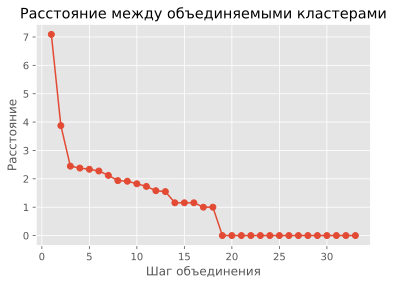

In [38]:
dist_rev = dist[::-1] # разворачиваем массив
idxs = range(1, len(dist) + 1)
plt.figure(figsize = (6,4))
plt.plot(idxs, dist_rev, marker='o')
plt.title('Расстояние между объединяемыми кластерами')
plt.xlabel('Шаг объединения')
plt.ylabel('Расстояние');

По графику видно, что локоть преломляется на позиции 3, следовательно оптимальное количество кластеров 3

### Пример 2

In [39]:
df = pd.read_csv('assess.dat', sep='\t', encoding=ENCODINGS[0], index_col='NAME')

In [40]:
df.head(5)

,NR,T1,T2,T3,T4,T5,T6,T7,T8,T9,T10
NAME,,,,,,,,,,,
Volker,1,10,10,9,10,10,10,9,10,10,9
Sigrid,2,10,10,4,10,5,5,4,5,4,3
Elmar,3,5,4,10,5,10,4,10,5,3,10
Peter,4,10,10,9,10,10,10,9,10,10,9
Otto,5,4,3,5,4,3,10,4,10,10,5


In [41]:
del df['NR']

In [42]:
df.head(5)

,T1,T2,T3,T4,T5,T6,T7,T8,T9,T10
NAME,,,,,,,,,,
Volker,10,10,9,10,10,10,9,10,10,9
Sigrid,10,10,4,10,5,5,4,5,4,3
Elmar,5,4,10,5,10,4,10,5,3,10
Peter,10,10,9,10,10,10,9,10,10,9
Otto,4,3,5,4,3,10,4,10,10,5


In [43]:
Z = linkage(df, method='ward', metric='euclidean')

In [44]:
print(Z)

[[ 0.          3.          0.          2.        ]
 [ 1.          9.          1.41421356  2.        ]
 [ 8.         13.          1.41421356  2.        ]
 [10.         17.          1.41421356  2.        ]
 [11.         14.          1.41421356  2.        ]
 [12.         15.          2.          2.        ]
 [20.         21.          2.23606798  4.        ]
 [18.         22.          2.23606798  4.        ]
 [ 4.          6.          2.23606798  2.        ]
 [ 5.         16.          2.44948974  2.        ]
 [ 7.         23.          2.82842712  3.        ]
 [ 2.         24.          2.93257566  5.        ]
 [19.         27.          3.31662479  4.        ]
 [26.         28.          4.79583152  5.        ]
 [25.         30.         28.01785145  8.        ]
 [31.         32.         29.92940412 13.        ]
 [29.         33.         33.23097103 18.        ]]


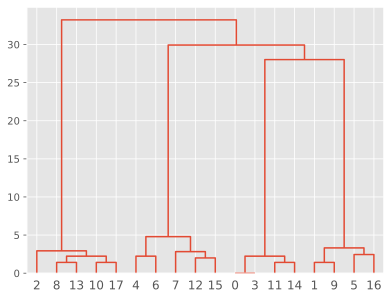

In [45]:
dn = dendrogram(Z, color_threshold=-1)

In [46]:
df['cluster'] = fcluster(Z, t=4, criterion='maxclust')

In [47]:
df.groupby('cluster').size()

cluster
1    5
2    5
3    4
4    4
dtype: int64

In [48]:
df

,T1,T2,T3,T4,T5,T6,T7,T8,T9,T10,cluster
NAME,,,,,,,,,,,
Volker,10,10,9,10,10,10,9,10,10,9,3
Sigrid,10,10,4,10,5,5,4,5,4,3,4
Elmar,5,4,10,5,10,4,10,5,3,10,1
Peter,10,10,9,10,10,10,9,10,10,9,3
Otto,4,3,5,4,3,10,4,10,10,5,2
Elke,10,10,4,10,5,4,3,4,5,5,4
Sarah,4,4,5,5,4,10,5,10,10,6,2
Peter,4,5,3,4,5,10,4,10,10,4,2
Gudrun,4,5,10,4,10,5,10,4,3,10,1


In [49]:
df.groupby('cluster').mean()

,T1,T2,T3,T4,T5,T6,T7,T8,T9,T10
cluster,,,,,,,,,,
1,4.2,4.8,10.00,4.4,10.00,4.4,10.00,4.00,3.80,10.00
2,4.8,4.4,4.00,4.0,4.20,10.0,4.40,10.00,10.00,5.00
3,10.0,10.0,9.00,10.0,10.00,9.5,9.25,9.75,10.00,9.50
4,10.0,10.0,4.25,10.0,4.75,4.5,3.75,4.25,4.25,4.25


In [50]:
dist = Z[:, 2]
dist

array([ 0.        ,  1.41421356,  1.41421356,  1.41421356,  1.41421356,
        2.        ,  2.23606798,  2.23606798,  2.23606798,  2.44948974,
        2.82842712,  2.93257566,  3.31662479,  4.79583152, 28.01785145,
       29.92940412, 33.23097103])

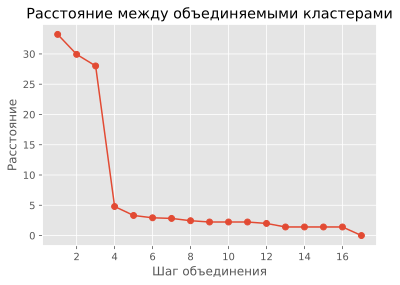

In [51]:
dist_rev = dist[::-1]
idxs = range(1, len(dist) + 1)
plt.figure(figsize = (6,4))
plt.plot(idxs, dist_rev, marker='o')
plt.title('Расстояние между объединяемыми кластерами')
plt.xlabel('Шаг объединения')
plt.ylabel('Расстояние');

График подтверждает выбор 4х кластеров

### Пример 3

In [52]:
from src.config import FILE_PROTEIN

In [68]:
df = pd.read_csv(FILE_PROTEIN, sep=';', encoding=ENCODINGS[0], decimal=',', index_col='Country')
df.head(5)

,RedMeat,WhiteMeat,Eggs,Milk,Fish,Cereals,Starch,Nuts,Fr&Veg
Country,,,,,,,,,
Albania,10.1,1.4,0.5,8.9,0.2,42.3,0.6,5.5,1.7
Austria,8.9,14.0,4.3,19.9,2.1,28.0,3.6,1.3,4.3
Belgium,13.5,9.3,4.1,17.5,4.5,26.6,5.7,2.1,4.0
Bulgaria,7.8,6.0,1.6,8.3,1.2,56.7,1.1,3.7,4.2
Czechoslovakia,9.7,11.4,2.8,12.5,2.0,34.3,5.0,1.1,4.0


In [69]:
df.dtypes

RedMeat      float64
WhiteMeat    float64
Eggs         float64
Milk         float64
Fish         float64
Cereals      float64
Starch       float64
Nuts         float64
Fr&Veg       float64
dtype: object

In [71]:
df.describe().T[["mean","std","min","max"]]

,mean,std,min,max
RedMeat,9.828,3.347078,4.4,18.0
WhiteMeat,7.896,3.694081,1.4,14.0
Eggs,2.936,1.117617,0.5,4.7
Milk,17.112,7.105416,4.9,33.7
Fish,4.284,3.402533,0.2,14.2
Cereals,32.248,10.974786,18.6,56.7
Starch,4.276,1.634085,0.6,6.5
Nuts,3.072,1.985682,0.7,7.8
Fr&Veg,4.136,1.803903,1.4,7.9


In [78]:
from sklearn import preprocessing

In [79]:
stand_1 = preprocessing.StandardScaler()
stand_2 = preprocessing.MaxAbsScaler()
stand_3 = preprocessing.MinMaxScaler()

In [81]:
stand_1.fit(df)
stand_2.fit(df)
stand_3.fit(df)

MinMaxScaler()

In [82]:
X = stand_1.transform(df)
X_2 = stand_2.transform(df)
X_3 = stand_3.transform(df)

In [77]:
X

array([[ 0.08294065, -1.79475017, -2.22458425, -1.1795703 , -1.22503282,
         0.9348045 , -2.29596509,  1.24796771, -1.37825141],
       [-0.28297397,  1.68644628,  1.24562107,  0.40046785, -0.6551106 ,
        -0.39505069, -0.42221774, -0.91079027,  0.09278868],
       [ 1.11969872,  0.38790475,  1.06297868,  0.05573225,  0.06479116,
        -0.5252463 ,  0.88940541, -0.49959828, -0.07694671],
       [-0.6183957 , -0.52383718, -1.22005113, -1.2657542 , -0.92507375,
         2.27395937, -1.98367386,  0.32278572,  0.03621022],
       [-0.03903089,  0.96810416, -0.12419682, -0.6624669 , -0.6851065 ,
         0.19082957,  0.45219769, -1.01358827, -0.07694671],
       [ 0.23540507,  0.8023329 ,  0.69769391,  1.13303099,  1.68457011,
        -0.96233157,  0.3272812 , -1.21918427, -0.98220215],
       [-0.43543839,  1.02336124,  0.69769391, -0.86356267,  0.33475432,
        -0.71124003,  1.38907137, -1.16778527, -0.30326057],
       [-0.10001666, -0.82775116, -0.21551801,  2.38269753,  0

In [83]:
X_2

array([[0.56111111, 0.1       , 0.10638298, 0.26409496, 0.01408451,
        0.74603175, 0.09230769, 0.70512821, 0.21518987],
       [0.49444444, 1.        , 0.91489362, 0.59050445, 0.14788732,
        0.49382716, 0.55384615, 0.16666667, 0.5443038 ],
       [0.75      , 0.66428571, 0.87234043, 0.51928783, 0.31690141,
        0.4691358 , 0.87692308, 0.26923077, 0.50632911],
       [0.43333333, 0.42857143, 0.34042553, 0.2462908 , 0.08450704,
        1.        , 0.16923077, 0.47435897, 0.53164557],
       [0.53888889, 0.81428571, 0.59574468, 0.37091988, 0.14084507,
        0.60493827, 0.76923077, 0.14102564, 0.50632911],
       [0.58888889, 0.77142857, 0.78723404, 0.74183976, 0.6971831 ,
        0.38624339, 0.73846154, 0.08974359, 0.30379747],
       [0.46666667, 0.82857143, 0.78723404, 0.32937685, 0.38028169,
        0.43386243, 1.        , 0.1025641 , 0.4556962 ],
       [0.52777778, 0.35      , 0.57446809, 1.        , 0.4084507 ,
        0.4638448 , 0.78461538, 0.12820513, 0.17721519],


In [84]:
X_3

array([[0.41911765, 0.        , 0.        , 0.13888889, 0.        ,
        0.62204724, 0.        , 0.67605634, 0.04615385],
       [0.33088235, 1.        , 0.9047619 , 0.52083333, 0.13571429,
        0.24671916, 0.50847458, 0.08450704, 0.44615385],
       [0.66911765, 0.62698413, 0.85714286, 0.4375    , 0.30714286,
        0.20997375, 0.86440678, 0.1971831 , 0.4       ],
       [0.25      , 0.36507937, 0.26190476, 0.11805556, 0.07142857,
        1.        , 0.08474576, 0.42253521, 0.43076923],
       [0.38970588, 0.79365079, 0.54761905, 0.26388889, 0.12857143,
        0.41207349, 0.74576271, 0.05633803, 0.4       ],
       [0.45588235, 0.74603175, 0.76190476, 0.69791667, 0.69285714,
        0.08661417, 0.71186441, 0.        , 0.15384615],
       [0.29411765, 0.80952381, 0.76190476, 0.21527778, 0.37142857,
        0.15748031, 1.        , 0.01408451, 0.33846154],
       [0.375     , 0.27777778, 0.52380952, 1.        , 0.4       ,
        0.20209974, 0.76271186, 0.04225352, 0.        ],


In [88]:
stand_1.mean_

array([ 9.828,  7.896,  2.936, 17.112,  4.284, 32.248,  4.276,  3.072,
        4.136])

In [90]:
stand_1.scale_

array([ 3.27945361,  3.61944526,  1.09503607,  6.96185722,  3.33378824,
       10.75305054,  1.60106964,  1.94556316,  1.76745693])

Сюда записаны наши средние и стд по каждому столбцу, можно посмотреть все данные, которые собирает каждый конкретный метод

In [99]:
X = pd.DataFrame(X, index=df.index, columns=df.columns)
X_2 = pd.DataFrame(X_2, index=df.index, columns=df.columns)
X_3 = pd.DataFrame(X_3, index=df.index, columns=df.columns)

In [100]:
X.head(5)

,RedMeat,WhiteMeat,Eggs,Milk,Fish,Cereals,Starch,Nuts,Fr&Veg
Country,,,,,,,,,
Albania,0.082941,-1.794750,-2.224584,-1.179570,-1.225033,0.934804,-2.295965,1.247968,-1.378251
Austria,-0.282974,1.686446,1.245621,0.400468,-0.655111,-0.395051,-0.422218,-0.910790,0.092789
Belgium,1.119699,0.387905,1.062979,0.055732,0.064791,-0.525246,0.889405,-0.499598,-0.076947
Bulgaria,-0.618396,-0.523837,-1.220051,-1.265754,-0.925074,2.273959,-1.983674,0.322786,0.036210
Czechoslovakia,-0.039031,0.968104,-0.124197,-0.662467,-0.685107,0.190830,0.452198,-1.013588,-0.076947


In [101]:
X_2.head(5)

,RedMeat,WhiteMeat,Eggs,Milk,Fish,Cereals,Starch,Nuts,Fr&Veg
Country,,,,,,,,,
Albania,0.561111,0.100000,0.106383,0.264095,0.014085,0.746032,0.092308,0.705128,0.215190
Austria,0.494444,1.000000,0.914894,0.590504,0.147887,0.493827,0.553846,0.166667,0.544304
Belgium,0.750000,0.664286,0.872340,0.519288,0.316901,0.469136,0.876923,0.269231,0.506329
Bulgaria,0.433333,0.428571,0.340426,0.246291,0.084507,1.000000,0.169231,0.474359,0.531646
Czechoslovakia,0.538889,0.814286,0.595745,0.370920,0.140845,0.604938,0.769231,0.141026,0.506329


In [102]:
X_3.head(5)

,RedMeat,WhiteMeat,Eggs,Milk,Fish,Cereals,Starch,Nuts,Fr&Veg
Country,,,,,,,,,
Albania,0.419118,0.000000,0.000000,0.138889,0.000000,0.622047,0.000000,0.676056,0.046154
Austria,0.330882,1.000000,0.904762,0.520833,0.135714,0.246719,0.508475,0.084507,0.446154
Belgium,0.669118,0.626984,0.857143,0.437500,0.307143,0.209974,0.864407,0.197183,0.400000
Bulgaria,0.250000,0.365079,0.261905,0.118056,0.071429,1.000000,0.084746,0.422535,0.430769
Czechoslovakia,0.389706,0.793651,0.547619,0.263889,0.128571,0.412073,0.745763,0.056338,0.400000


На данном этапе стандартизация закончена

In [103]:
Z = linkage(X, method='ward', metric='euclidean')
Z

array([[17.        , 24.        ,  1.00656827,  2.        ],
       [ 1.        , 13.        ,  1.14647572,  2.        ],
       [ 5.        , 19.        ,  1.41015822,  2.        ],
       [ 2.        , 23.        ,  1.44719737,  2.        ],
       [11.        , 28.        ,  1.86462557,  3.        ],
       [14.        , 27.        ,  1.91517805,  3.        ],
       [ 4.        ,  6.        ,  1.9190385 ,  2.        ],
       [ 9.        , 12.        ,  2.19446093,  2.        ],
       [ 3.        , 25.        ,  2.21352258,  3.        ],
       [20.        , 26.        ,  2.33259168,  3.        ],
       [ 7.        , 30.        ,  2.57601959,  4.        ],
       [ 8.        , 21.        ,  2.62426927,  2.        ],
       [15.        , 31.        ,  2.63512692,  3.        ],
       [16.        , 18.        ,  2.99324882,  2.        ],
       [29.        , 34.        ,  3.18929396,  6.        ],
       [ 0.        , 33.        ,  3.28315133,  4.        ],
       [22.        , 37.

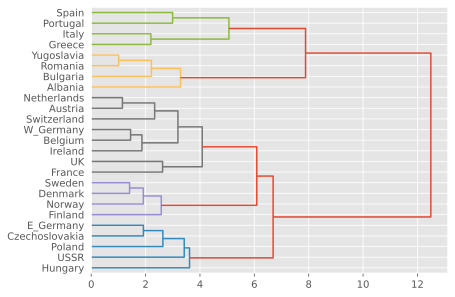

In [114]:
dn = dendrogram(Z, color_threshold=5.5, orientation='right', labels=df.index.tolist())

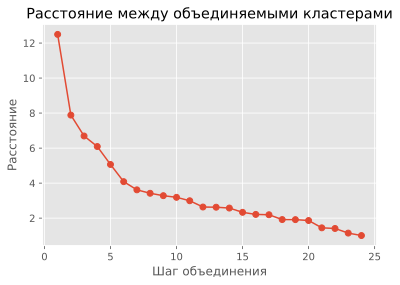

In [106]:
dist = Z[:, 2]
dist_rev = dist[::-1]
idxs = range(1, len(dist) + 1)
plt.figure(figsize = (6,4))
plt.plot(idxs, dist_rev, marker='o')
plt.title('Расстояние между объединяемыми кластерами')
plt.xlabel('Шаг объединения')
plt.ylabel('Расстояние');

In [113]:
X.groupby(fcluster(Z, t=5, criterion='maxclust')).mean()

,RedMeat,WhiteMeat,Eggs,Milk,Fish,Cereals,Starch,Nuts,Fr&Veg
1,-0.581804,0.592356,-0.087668,-0.469990,-0.463137,0.324745,0.801964,-0.273443,0.070157
2,0.006708,-0.233737,0.195427,1.373628,1.182139,-0.890259,0.171136,-0.975039,-1.137793
3,1.032032,0.757437,0.960242,0.581813,-0.272663,-0.701940,0.233594,-0.518873,0.022066
4,-0.824223,-0.889915,-1.585336,-1.100568,-1.060055,1.755502,-1.452779,1.016672,-0.656876
5,-0.519294,-1.131665,-0.420991,-0.849199,1.002163,0.132707,-0.187999,1.337916,1.662841
